# Pulling Real Census Data

Tonight's question: **in which California counties do the most homes heat with electricity?**

We will answer it with real federal data, live, using the Census Bureau's API. To run a cell, click it and press **Shift+Enter**. Run cells top to bottom. Everything this notebook needs is already installed in Colab.

## Speedrunning basic concepts

In [18]:
county = "Alameda"     # text information goes in quotes
homes = 600000         # numbers don't
# above, we are assigning these values to different variables that we can reuse
homes / 2              # we can do all sorts of basic mathematical operations

300000.0

In [19]:
# if we want to repeat something we can make a function (and packages, like pandas, are just complex versions of these)
def divide_by_2(x):
    return x / 2

divide_by_2(homes)

300000.0

## Refresher: what is an API?

An API is a URL that returns **data** instead of a webpage. Here is the exact request we are about to make, taken apart:

```
https://api.census.gov/data/2024/acs/acs5?get=NAME,B25040_001E,B25040_004E&for=county:*&in=state:06&key=...
      |________________| |_____________|     |_________________________|     |_________| |_________| |____|
        the server        the dataset:           which variables:             for every    ...in      your
                          2020-2024 ACS        county name, total homes,       county    California    key
                          5-year estimates     homes heating w/ electricity                (FIPS 06)
```

**Try it yourself first:** paste the full URL (with your API key) into a new browser tab. You will get back raw data, not a webpage. Everything below is just doing that same URL in code, which makes it repeatable, shareable, and citable.

In [20]:
# Three packages: one to make web requests, one to work with tables, one to make charts
import requests
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Sign up for a free key here https://api.census.gov/data/key_signup.html, click the activate button in the email, and paste it below
API_KEY = "your_key_here"

In [ ]:
# SETTINGS: this is the only cell you need to change for "your turn" at the end
STATE_FIPS = "06"            # California (two digits, in quotes)
STATE_NAME = "California"
FUEL_CODE  = "B25040_004E"   # electricity (other fuels are in the table further down)
FUEL_NAME  = "electric"      # used to name columns and label the chart

The American Community Survey (ACS) is the Census Bureau's ongoing survey of housing, work, commuting, income, and more. It samples roughly 3.5 million addresses a year (about 1 in 40 households). The **5-year estimates** pool five years of responses (here 2020-2024) so that small places have enough sample to report; the trade-off is that small counties still come with wide margins of error.

In [23]:
url = "https://api.census.gov/data/2024/acs/acs5"   # 2020-2024 ACS 5-year estimates

# params is a dictionary: a set of labeled values, like filling in a form
params = {
    "get": "NAME,B25040_001E," + FUEL_CODE,   # county name, total occupied homes, homes using our fuel
    "for": "county:*",                        # every county...
    "in": "state:" + STATE_FIPS,              # ...in our state
    "key": API_KEY,
}

response = requests.get(url, params=params)      # requests.get is a function; url and params are its arguments
print("Status code:", response.status_code)     # 200 means it worked

# if it worked, keep the data; if not, print the Census Bureau's explanation instead of a scary traceback
if response.status_code == 200:
    data = response.json()
    print(data[:3])                              # peek at the first three rows of what came back
else:
    print("The API said no. Check API_KEY and the SETTINGS cell. The message it sent back:")
    print(response.text[:300])

Status code: 200
[['NAME', 'B25040_001E', 'B25040_003E', 'state', 'county'], ['Adams County, Colorado', '188730', '3835', '08', '001'], ['Alamosa County, Colorado', '6648', '912', '08', '003']]


## Where did `B25040` come from?

Nobody memorizes variable codes. The Census publishes a list of every variable in every dataset; the page for this table is [api.census.gov/data/2024/acs/acs5/groups/B25040.html](https://api.census.gov/data/2024/acs/acs5/groups/B25040.html), and the full searchable variable list for the whole dataset is linked from the [2024 ACS 5-year API page](https://www.census.gov/data/developers/data-sets/acs-5year/2024.html).

Table **B25040: House Heating Fuel** (universe: occupied housing units):

| Variable | Meaning |
|---|---|
| `B25040_001E` | Total occupied homes |
| `B25040_002E` | Utility gas |
| `B25040_003E` | Bottled, tank, or LP gas |
| `B25040_004E` | **Electricity** |
| `B25040_005E` | Fuel oil, kerosene, etc. |
| `B25040_006E` | Coal or coke |
| `B25040_007E` | Wood |
| `B25040_008E` | Solar energy |
| `B25040_009E` | Other fuel |
| `B25040_010E` | No fuel used |

The `E` on the end means *estimate*. Every variable also has an `M` twin (`B25040_004M`) holding its **margin of error**, and for a county of 1,100 people that margin can be as large as the estimate itself. Keep that in mind when a tiny county tops the chart.

In [24]:
# The API returned a list of lists; the first row is the column headers
df = pd.DataFrame(data[1:], columns=data[0])
df.head() #head returns just the first 5 rows 

,NAME,B25040_001E,B25040_003E,state,county
0,"Adams County, Colorado",188730,3835,08,001
1,"Alamosa County, Colorado",6648,912,08,003
2,"Arapahoe County, Colorado",257232,3901,08,005
3,"Archuleta County, Colorado",5921,1880,08,007
4,"Baca County, Colorado",1657,258,08,009


In [25]:
# Rebuild the table from the raw data every time, so this cell gives the same answer no matter how often you run it
df = pd.DataFrame(data[1:], columns=data[0])

# Safety check: does the data we have actually match the SETTINGS cell?
if FUEL_CODE not in df.columns or df["state"].iloc[0] != STATE_FIPS.zfill(2):
    raise ValueError("The data above was pulled with different settings than the SETTINGS cell now has. "
                     "Re-run from the request cell, or use Runtime > Run all.")

# The API returns everything as TEXT, even the numbers. Data types matter in python.
fuel_col  = FUEL_NAME + "_homes"      # e.g. "electric_homes"
share_col = "share_" + FUEL_NAME      # e.g. "share_electric"

df = df.rename(columns={"B25040_001E": "total_homes", FUEL_CODE: fuel_col})
df["total_homes"] = pd.to_numeric(df["total_homes"])
df[fuel_col]      = pd.to_numeric(df[fuel_col])

# The actual analysis is one line of arithmetic:
df[share_col] = df[fuel_col] / df["total_homes"]

# Cosmetic: "Alameda County, California" -> "Alameda County"
df["county"] = df["NAME"].str.replace(", " + STATE_NAME, "", regex=False)

df.head()

,NAME,total_homes,electric_homes,state,county,share_electric
0,"Adams County, Colorado",188730,3835,08,"Adams County, Colorado",0.020320
1,"Alamosa County, Colorado",6648,912,08,"Alamosa County, Colorado",0.137184
2,"Arapahoe County, Colorado",257232,3901,08,"Arapahoe County, Colorado",0.015165
3,"Archuleta County, Colorado",5921,1880,08,"Archuleta County, Colorado",0.317514
4,"Baca County, Colorado",1657,258,08,"Baca County, Colorado",0.155703


## Does `sort_values` sort biggest-first or smallest-first?

Run `help(df.sort_values)` in a cell, or read the [official pandas documentation for `sort_values`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sort_values.html)

In [26]:
top10 = df.sort_values(share_col, ascending=False).head(10)
top10[["county", "total_homes", fuel_col, share_col]]

,county,total_homes,electric_homes,share_electric
14,"Custer County, Colorado",2672,1809,0.677021
27,"Hinsdale County, Colorado",511,279,0.545988
56,"San Juan County, Colorado",399,195,0.488722
61,"Washington County, Colorado",2070,793,0.383092
20,"Elbert County, Colorado",10004,3768,0.376649
28,"Huerfano County, Colorado",3100,1065,0.343548
12,"Costilla County, Colorado",1651,551,0.333737
17,"Dolores County, Colorado",1254,405,0.322967
3,"Archuleta County, Colorado",5921,1880,0.317514
47,"Park County, Colorado",8988,2713,0.301847


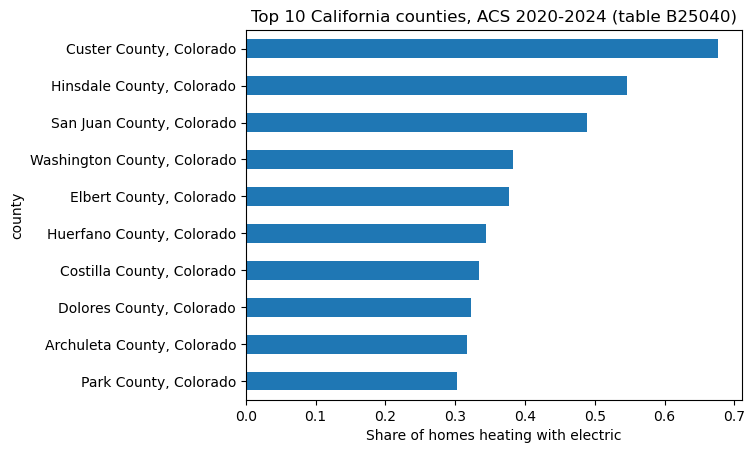

In [27]:
# pandas can draw a chart straight from a DataFrame (it uses matplotlib underneath)
fuel_label = share_col.replace("share_", "")   # the label comes from the column we plot, so it can never disagree with the data
top10.sort_values(share_col).plot.barh(x="county", y=share_col, legend=False)   # re-sorted so the biggest bar is on top
plt.xlabel("Share of homes heating with " + fuel_label)
plt.title("Top 10 " + STATE_NAME + " counties, ACS 2020-2024 (table B25040)")
plt.show()

## Your turn!

Working code is yours to modify (much analysis is built on top of other analysis). Scroll back up to the **SETTINGS** cell, change it, then choose **Runtime > Run all** from the menu.

**Why Run all and not just the cell you changed?** Every cell here builds on the ones above it. If you change the settings and re-run only a later cell, that cell is still holding the *old* data, and you will either get a `KeyError` or a red safety-check message telling you to re-run from the request cell. Run all restarts the chain from the top.

**Change 1: your home state.** Set `STATE_FIPS` to your state's code from the table below and `STATE_NAME` to its name.

| State | FIPS | State | FIPS | State | FIPS | State | FIPS |
|---|---|---|---|---|---|---|---|
| AL | 01 | IN | 18 | NE | 31 | SC | 45 |
| AK | 02 | IA | 19 | NV | 32 | SD | 46 |
| AZ | 04 | KS | 20 | NH | 33 | TN | 47 |
| AR | 05 | KY | 21 | NJ | 34 | TX | 48 |
| CA | 06 | LA | 22 | NM | 35 | UT | 49 |
| CO | 08 | ME | 23 | NY | 36 | VT | 50 |
| CT | 09 | MD | 24 | NC | 37 | VA | 51 |
| DE | 10 | MA | 25 | ND | 38 | WA | 53 |
| DC | 11 | MI | 26 | OH | 39 | WV | 54 |
| FL | 12 | MN | 27 | OK | 40 | WI | 55 |
| GA | 13 | MS | 28 | OR | 41 | WY | 56 |
| HI | 15 | MO | 29 | PA | 42 | PR | 72 |
| ID | 16 | MT | 30 | RI | 44 |  |  |
| IL | 17 |  |  |  |  |  |  |

**Change 2: a different fuel.** Set `FUEL_CODE` to one of the codes from the B25040 table above (`B25040_007E` for wood, `B25040_002E` for utility gas, `B25040_008E` for solar) and `FUEL_NAME` to a short label like `"wood"`.

Which county in your state heats its homes the most with your chosen fuel? Is it a big county or a tiny one?

*Notice that you changed the state and the fuel in exactly one place, and everything downstream updated. That is the code version of putting an assumption in one labeled cell instead of typing it into 59 formulas.*

---
## Turning the chart into a reusable function

The chart cell above works for one chart. If you wanted to make the same chart many times (every state, every fuel), you'd wrap it in a function, exactly like `divide_by_2` at the top of this notebook, just longer. The text between the triple quotes is a *docstring*: documentation that lives with the code, which is where `help()` gets its answers.

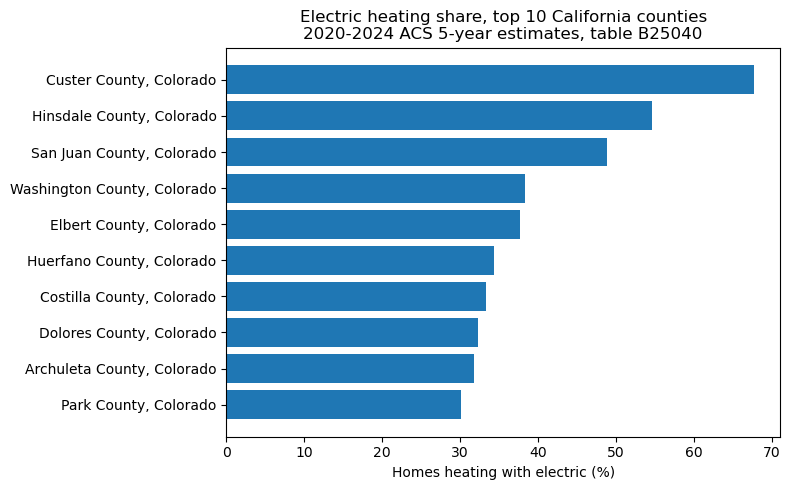

In [28]:
def plot_county_bars(df, state_name, energy_type):
    """
    Draw a horizontal bar chart of the counties with the highest share of
    homes heating with a given fuel.

    Parameters
    ----------
    df : pandas DataFrame
        Must have a "county" column and a "share_<energy_type>" column
        (e.g. "share_electric") holding a fraction between 0 and 1.
        Pass in only the rows you want plotted (e.g. the top 10).
    state_name : str
        Used in the chart title, e.g. "California".
    energy_type : str
        The fuel to plot, matching the column suffix, e.g. "electric",
        "gas", "wood".

    Returns
    -------
    None. Displays the chart.

    Example usage
    -------------
    top10 = df.sort_values("share_electric", ascending=False).head(10)
    plot_county_bars(top10, "California", "electric")
    """
    share_col = f"share_{energy_type}"
    plot_data = df.sort_values(share_col)
    plt.figure(figsize=(8, 5))
    plt.barh(plot_data["county"], plot_data[share_col] * 100)
    plt.xlabel(f"Homes heating with {energy_type} (%)")
    plt.title(f"{energy_type.capitalize()} heating share, top 10 {state_name} counties\n"
              f"2020-2024 ACS 5-year estimates, table B25040")
    plt.tight_layout()
    plt.show()

plot_county_bars(top10, STATE_NAME, FUEL_NAME)